In [1]:
%load_ext autoreload
%autoreload 2
from graph_factory import GraphFactory, add_graph_plot

import math
import threading
import time
import warnings
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
import yaml
import json
from datetime import datetime
import scipy.linalg as sla
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import softmax, log_softmax, logsumexp
from sklearn.datasets import fetch_openml
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, log_loss
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

In [2]:
global_seed = 0
global_rng = np.random.default_rng(global_seed)

## Setup

### Global Dataset

In [3]:
mnist = fetch_openml('mnist_784',parser = 'auto')
X = mnist.data
y = mnist.target.astype(int).to_numpy()
C = np.unique(y).shape[0]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=global_seed)

global_preproc = make_pipeline(
    MinMaxScaler(),
    PCA(n_components=0.93, svd_solver="full", random_state=global_seed, whiten=True), # every retained component has unit variance
)

X_pca = global_preproc.fit_transform(X_train)
X_aug = np.hstack([X_pca, np.ones((X_pca.shape[0], 1))])
X_pca_test = global_preproc.transform(X_test)
X_aug_test = np.hstack([X_pca_test, np.ones((X_pca_test.shape[0], 1))])

### Helper Functions

In [5]:
def get_alphas(K, config):
    return config['alpha_init'] / (1.0 + (np.arange(K)*config['alpha_decay']))

In [6]:
def dirichlet_partition(labels, n_clients, alpha):
    labels = np.asarray(labels)
    client_idx = [[] for _ in range(n_clients)]

    for c in np.unique(labels):
        idx_c = np.where(labels == c)[0]
        global_rng.shuffle(idx_c)
        # proportion of class c assigned to each client
        proportions = global_rng.dirichlet(alpha * np.ones(n_clients))
        # split points (cumulative, dropping the last)
        splits = (np.cumsum(proportions)[:-1] * len(idx_c)).astype(int)
        for client, part in enumerate(np.split(idx_c, splits)):
            client_idx[client].extend(part.tolist())

    return [np.array(ci) for ci in client_idx]

In [7]:
def global_ce(theta, X, y):
    """Mean softmax cross-entropy; theta shape (d+1, C)."""
    z = X @ theta
    z -= z.max(axis=1, keepdims=True)          # numerical stability
    log_probs = z - np.log(np.exp(z).sum(axis=1, keepdims=True))
    return -log_probs[np.arange(len(y)), y].mean()

In [8]:
def sgd_grad(X, y, theta, mu, batch_sz, rng):
    """Stochastic gradient of (1/n)Σ l_i + (mu/2)||theta||^2 on a uniform mini-batch.
       X:(n,d) bias-augmented, theta:(d,K), y:(n,) int, batch:int, rng:np.random.Generator."""
    n, K = X.shape[0], theta.shape[1]
    idx = rng.integers(0, n, size=batch_sz)  # uniform sample
    Xb, yb = X[idx], y[idx]
    Z  = Xb @ theta
    Yb = np.eye(K)[yb]
    loss = -(Yb * log_softmax(Z, axis=1)).sum() / batch_sz + 0.5 * mu * np.linalg.norm(theta)**2
    grad = Xb.T @ (softmax(Z, axis=1) - Yb) / batch_sz + mu * theta
    return loss, grad

In [9]:
def proj_tau(x_i, x_j, tau):
    d = x_j - x_i
    nd = np.linalg.norm(d)                # Frobenius for (d+1, C) matrices
    return x_i if nd == 0 else x_i + min(1.0, tau / nd) * d

In [10]:
def effective_mixing(W0, H, gamma_C):
    Wh = W0[np.ix_(H, H)]
    h = len(H)

    #  W_bar = E[What^k]
    Wbar = (1.0 - gamma_C) * Wh
    np.fill_diagonal(Wbar, 0.0)
    np.fill_diagonal(Wbar, 1.0 - Wbar.sum(1))

    # Left Perron vector pi
    ev, evec = sla.eig(Wbar.T)
    j = int(np.argmin(np.abs(ev - 1.0)))
    if abs(ev[j] - 1.0) > 1e-8:
        raise ValueError("no eigenvalue 1: honest subgraph is probably disconnected")
    pi = np.real(evec[:, j])
    pi = pi / pi.sum()
    if pi.min() <= 0:
        raise ValueError("non-positive stationary mass: honest subgraph reducible")

    # lambda_pi: contraction of W_bar on D_pi (in pi-weighted norm)
    sp = np.sqrt(pi)
    Pi = np.eye(h) - np.outer(np.ones(h), pi)
    Msim = (sp[:, None] * ((Wbar - np.outer(np.ones(h), pi)) @ Pi)) / sp[None, :]
    lam_pi = np.linalg.norm(Msim, 2)

    return Wbar, pi, lam_pi

In [11]:
def nu2_pi_tot(W0, H, pi, gamma_C):
    Wh = W0[np.ix_(H, H)]
    h = len(H)

    Q = np.zeros((h, h))
    for a in range(h):
        for c in range(h):
            if a != c and Wh[a, c] > 0:
                e = np.zeros(h)
                e[a] = 1.0
                e[c] = 1.0
                Q += pi[a] * Wh[a, c] ** 2 * np.outer(e, e)
    Q *= gamma_C * (1.0 - gamma_C)

    nu2 = float(sla.eigh(Q, np.diag(pi), eigvals_only=True).max())

    w_max = float((Wh - np.diag(np.diag(Wh))).max())
    upper_bound = 4.0 * (pi.max() / pi.min()) * w_max * gamma_C * (1.0 - gamma_C)

    return nu2, upper_bound

In [12]:
def calc_L_mu(theta_stack, X_shards, reg_param):
    """theta_stack: (h, D, C) = models[H];  X_shards: list of per-node X_aug[dp[i]]."""
    Ls, mus = [], []
    for th, Xi in zip(theta_stack, X_shards):
        D, C = th.shape
        Ls.append(reg_param + 0.5 * np.linalg.eigvalsh(Xi.T @ Xi / Xi.shape[0]).max())
        mus.append(reg_param)
    return float(max(Ls)), float(min(mus))

In [13]:
def calc_rdsgd_constants(W0, H, B, theta, X_shards, gamma_C, beta_C, proj_const):
    Wbar, pi, lam_pi = effective_mixing(W0, H, gamma_C)
    nu2, upper_bound = nu2_pi_tot(W0, H, pi, gamma_C)
    L, mu = calc_L_mu(theta, X_shards, config['reg_param'])
    
    s2 = lam_pi ** 2 + nu2
    g = 1.0 - s2
    
    dB_max = max(W0[i, B].sum() for i in H) if len(B) else 0.0
    dB_pi = float(sum(pi[k] * W0[i, B].sum() for k, i in enumerate(H))) if len(B) else 0.0

    n = min(dp[i].shape[0] for i in H)
    h = len(H)
    m = h
    a = config['alpha_init']
    tau = proj_const * a

    # TODO: add as an assumption to paper
    assert beta_C * dB_max <= (a*mu)/4, f"{beta_C * dB_max} > {(a*mu)/4}" 
    
    eps_opt = (8*L*(1+(beta_C*dB_max))) / (mu*m*n)
    eps_byz = (8*m*tau*beta_C*dB_pi) / (a*mu*n)
    byz_cons_floor = ((proj_const**2)*beta_C*(dB_max**2))/(mu**2) 
    return dict(g=g, s2=s2,                          
                pi=pi,                               # left Perron vector (lemma 1)
                lam_pi=lam_pi,                       # exact calculation (lemma 5)
                nu2=nu2,                             # exact calculation (lemma 2)
                nu2_bound=upper_bound,               # Lemma 3 upper bound on nu^2
                L=L,                                 # L-smoothness
                mu=mu,                               # mu-convexity mu
                tau=tau,                             # projection radius at k=0
                m=m,                                 # number of honest nodes
                n_loc=n,                             # minimum dirichlet shard size 
                dB_max=dB_max, 
                dB_pi=dB_pi,
                eps_opt=eps_opt, 
                eps_byz=eps_byz, 
                epsilon=eps_opt + eps_byz,           # on average stability upper bound
                byz_cons_floor=byz_cons_floor,       # corollary 10 V^inf upper bound
                alpha_max_conv=g/(6*L),              # a_k <= g/(6*L) forall k required for thm 9
                alpha_max_stab=2/(mu+L))             # a_k <= 2/(mu+L) forall k required for thm 13

In [14]:
def get_metrics(models, H, mu, X_ref, y_ref, X_te, y_te, fstar=1.32879):
    tr_ce = global_ce(models[H].mean(0), X_ref, y_ref)
    out = {
        "test_acc": ((X_te  @ models[H].mean(0)).argmax(1) == y_te ).mean(),
        "train_acc": ((X_ref @ models[H].mean(0)).argmax(1) == y_ref).mean(),
        "train_ce":  tr_ce,
        "opt_gap": (tr_ce + 0.5 * mu * np.sum(models[H].mean(0)**2)) - fstar,
    }

    return out

In [15]:
def parse(dat):
    assert dat['train']['num_nodes'] == dat['sys']['num_nodes']
    assert dat['train']['K'] == dat['sys']['K']
    assert dat['train']['b'] == dat['sys']['b']
    
    row = dat.copy()
    row['n'] = dat['sys']['num_nodes']
    row['K'] = dat['sys']['K']
    row['b'] = dat['sys']['b']
    row['sim_gamma_C'] = dat['train']['gamma_C']   # simulation FPR used in Bernoulli dropout (imposed)
    row['sim_beta_C'] = dat['train']['beta_C']     # simulation FNR used in Bernoulli dropout (imposed)
    row['val_gamma_C'] = dat['classifier']['fpr']  # measured FPR (distinct sim testset)
    row['val_beta_C'] = dat['classifier']['fnr']   # measured FNR (distinct sim testset) 
    row['val_auc'] = dat['classifier']['auc']      # measured AUC (distinct sim testset) 
    row['tau_log'] = dat['classifier']['tau']      # ideal logistic reg. threshold tau that minimizes FNR on distinct sim testset
    del row['classifier']

    # Parse run results
    for alg in ['RDSGD', 'IOS', 'SCC', 'TriMean', 'CooMed']:
        row[f'{alg}_T3'] = dat['T3'][alg]['test_acc']
    for alg in ['RDSGD', 'IOS', 'SCC', 'TriMean', 'CooMed', 'DSGD']:
        row[f'{alg}_T0'] = dat['T0'][alg]['test_acc']
    del row['T0']
    del row['T3']
    
    # Parse system fields
    if 'atk_type' in row['sys'].keys():
        row['atk_type'] = row['sys']['atk_type']
    del row['sys']

    # Parse classifier training fields
    train_keys = list(row['train'].keys())
    if ('train_atks' in train_keys) and ('val_atks' in train_keys):
        row['train_atks'] = set(row['train']['train_atks'])
        row['val_atks'] = set(row['train']['val_atks'])
    else:
        row['train_atks'] = {row['atk_type']}
        row['val_atks'] = {row['atk_type']}
    del row['train']

    return row

## Byzantine Attacks

In [16]:
def byz_atk(i, barrier, models, int_models, alphas, atk_type):
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)

    match atk_type:
        case 'label_flip':
            yl_perm = (yl + rng.integers(1,C)) % C
            for k in range(K):
                _, g = sgd_grad(Xl, yl_perm, models[i], config['reg_param'], batch_sz, rng)
                int_models[i] = models[i] - alphas[0] * g
                barrier.wait()
                models[i] = sum(W[i, j] * int_models[j] for j in list(G.neighbors(i))+[i])
                barrier.wait()
                
        case 'sign_flip':
            flip_scale=1.0
            for k in range(K):
                _, g = sgd_grad(Xl, yl, models[i], config['reg_param'], batch_sz, rng)
                int_models[i] = models[i] + flip_scale * alphas[k] * g
                barrier.wait()
                models[i] = sum(W[i, j] * int_models[j] for j in list(G.neighbors(i))+[i])
                barrier.wait()
                
        case 'gaussian':
            shape = models[i].shape
            sigma=1.0
            around_honest=True
            for k in range(K):
                if around_honest:
                    _, g = sgd_grad(Xl, yl, models[i], config['reg_param'], batch_sz, rng)
                    base = models[i] - alphas[k] * g
                else:
                    base = 0.0
                int_models[i] = base + sigma * rng.standard_normal(models[i].shape)
                barrier.wait()
                models[i] = sum(W[i, j] * int_models[j] for j in list(G.neighbors(i))+[i])
                barrier.wait()                 

## Aggregation Rules

In [17]:
def aggregate(i, int_models, W, G, B, H, agg_rule, q_i=None, tau_scc=0.3, q_trim=None):
    nbrs = list(G.neighbors(i))
    # if q_i is None: q_i = sum(1 for j in nbrs if j in B)
    # if q_trim is None: q_trim = sum(1 for j in nbrs if j in B)
    
    if q_i is None: q_i = math.ceil(np.array([sum(1 for j in list(G.neighbors(i)) if j in B) for i in H]).mean())
    if q_trim is None: q_trim = math.ceil(np.array([sum(1 for j in list(G.neighbors(i)) if j in B) for i in H]).mean())
 
    match agg_rule:
        case "IOS":                                       # Alg. 2
            trusted = set(G.neighbors(i)) | {i}
            def wavg(U):
                return sum(W[i, j] * int_models[j] for j in U) \
                       / sum(W[i, j] for j in U)
            for _ in range(q_i):
                x_avg = wavg(trusted)
                cands = np.array([j for j in trusted if j != i])
                if cands.size == 0: break
                d = np.linalg.norm(int_models[cands] - x_avg, axis=(1, 2))
                trusted.discard(int(cands[d.argmax()]))
            return wavg(trusted)
 
        case "SCC":                                       # eq. (94)
            def _clip(x, tau):
                """CLIP(x, tau) = min(1, tau/||x||) x   (Wu-Chen-Ling eq. 95)."""
                n = np.linalg.norm(x)
                return x if n <= tau or n == 0.0 else (tau / n) * x
            return int_models[i] + sum(
                W[i, j] * _clip(int_models[j] - int_models[i], tau_scc)
                for j in nbrs)
 
        case "TriMean":                                   # eq. (91), App. C
            S = np.stack([int_models[j] for j in nbrs])   # (m, d+1, C)
            m = S.shape[0]
            if 2 * q_trim >= m:
                # raise ValueError(f"q_trim={orig} too large for {m} neighbours -> {q_trim}")
                q_trim = q_trim - 1
            Ssort = np.sort(S, axis=0)
            base = Ssort[q_trim:m - q_trim].mean(0) if q_trim else Ssort.mean(0)
            r = 1.0 / (m + 1 - 2 * q_trim)
            return (1.0 - r) * base + r * int_models[i]
 
        case "CooMed":                                    # eq. (8)
            S = np.stack([int_models[j] for j in nbrs])
            return (1.0 - W[i,i]) * np.median(S, axis=0) + W[i,i] * int_models[i]

## Experimental Setup

In [18]:
%%capture
config = {
    'alpha_init':0.5,         # 0.1, 0.3, 0.5, 1.0
    'alpha_decay': 0.1,       # 0.005, 0.01, 0.1, 1
    'graph_type':'random-regular',
    'graph_weights':'MH',
    'graph_args': {
        'rand_reg_deg': 4,
    },
    'reg_param':0.2,
    'batch_sz':100, 
    'data_heterogeneity': 1,  # 0.1, 0.5, 10, 100
    'sys' : {
        'num_nodes': 20,
        'b': 3,
        'K': 140,
        'atk_type':'sign_flip',
    },
    'train': {
        'gamma_C': 0.25,  
        'beta_C': 0.5,
        'train_atks': ['label_flip', 'sign_flip', 'gaussian'],
        'val_atks': ['label_flip', 'sign_flip', 'gaussian'],
        # 'num_nodes': 20,
        # 'b': 2,
        # 'K': 60,
    }
}
config['train']['num_nodes'] = config['sys']['num_nodes']
config['train']['b'] = config['sys']['b']
config['train']['K'] = config['sys']['K']

run_metrics = dict()
run_id = generate()
run_metrics['id'] = run_id
run_metrics['timestamp'] = pd.to_datetime(datetime.now())

isLogging = True
print_freq = 20

final_fig, final_ax = plt.subplots(2,2, figsize=(10,8))

## Baseline Local Compute and Optimal Solution

In [19]:
full_pipe = make_pipeline(
    global_preproc,
    StandardScaler(),
    LogisticRegression(
        C=5, # 1/mu
        l1_ratio=0,
        solver='lbfgs',
        max_iter=1000,
        random_state=global_seed
    )
)

In [20]:
full_pipe.fit(X_train, y_train)
y_pred = full_pipe.predict(X_test)
y_proba = full_pipe.predict_proba(X_test)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")

Test Accuracy : 0.9171


In [21]:
clf = full_pipe[-1]
X_ = full_pipe[:-1].transform(X_test)
ce = log_loss(y_test, clf.predict_proba(X_)) 
f_star = ce + 0.5 * config['reg_param'] * np.sum(clf.coef_**2)
x_star = np.vstack([clf.coef_.T, clf.intercept_])
assert (np.argmax((X_aug_test @ x_star),axis=1) == y_test).mean() == accuracy_score(y_test, y_pred)
run_metrics['fstar'] = f_star

## Projection Constant $c$ in $\tau=c\alpha$

In [22]:
# Parameters
num_nodes = config['train']['num_nodes']
b = config['train']['b']
K = config['train']['K']
batch_sz = config['batch_sz']
eta = 1.2

In [23]:
gf1 = GraphFactory(num_nodes, b, global_seed)

In [24]:
dp = dirichlet_partition(y_train, num_nodes, alpha=config['data_heterogeneity'])
G, W, _ = gf1.create_graph(config['graph_type'], config['graph_weights'], **config['graph_args'])
alphas = get_alphas(K, config)

# Shared Variables
barrier = threading.Barrier(num_nodes) 
tar_node = global_rng.integers(0,num_nodes)
models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
int_models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
r_samples = [[] for _ in range(num_nodes)]

In [25]:
def worker_DSGD_proj(i, barrier, tar_node, models, int_models, alphas, r_samples):
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    nbors = np.array(list(G.neighbors(i)))
    for k in range(K):
        loss, g = sgd_grad(Xl, yl, models[i], config['reg_param'], batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g
        barrier.wait()
        r_samples[i].extend(np.linalg.norm(int_models[j] - models[i]) / alphas[k] for j in nbors)
        barrier.wait()

In [26]:
# Run Setup
models.fill(0)
int_models.fill(0)

DSGD_threads = [threading.Thread(target=worker_DSGD_proj, 
                                 args=(i, barrier, tar_node, models, int_models, alphas, r_samples,))
                for i in np.arange(num_nodes)]

for thread in DSGD_threads:
    thread.start()
for thread in DSGD_threads:
    thread.join()

In [27]:
residuals = np.concatenate([np.asarray(s) for i, s in enumerate(r_samples) if i in range(num_nodes)])
proj_const = eta * np.quantile(residuals, 0.8)
print(f"Projection const {proj_const:.4f}")
run_metrics['proj_const'] = proj_const

Projection const 1.7632


## Byzantine Classifier $\mathcal{C}$

### System Setup

In [28]:
# Parameters
num_nodes = config['train']['num_nodes']
b = config['train']['b']
K = config['train']['K']
batch_sz = config['batch_sz']
iter_sample_sz = K//2
config['train']['iter_sample_sz'] = iter_sample_sz

In [29]:
gf2 = GraphFactory(num_nodes, b, global_seed)

In [30]:
sampled_iters = global_rng.choice(K, size=iter_sample_sz, replace=False)

dp = dirichlet_partition(y_train, num_nodes, alpha=config['data_heterogeneity'])
G, W, sampling_subset = gf2.create_graph(config['graph_type'], config['graph_weights'], **config['graph_args'])
B = global_rng.choice(sampling_subset, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
alphas = get_alphas(K, config)
taus = proj_const * alphas

X_H = np.vstack([X_aug[dp[i]] for i in H])
y_H = np.concatenate([y_train[dp[i]] for i in H])

# Shared Variables
barrier = threading.Barrier(num_nodes) 
models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
int_models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
sampled_models = np.zeros((num_nodes, iter_sample_sz, X_pca.shape[1] + 1, C))
sampled_labels = np.zeros((num_nodes, iter_sample_sz, 1))
sampled_feats = np.zeros((num_nodes, len(sampled_iters)*max(dict(G.degree()).values()), 41))

### Feature Engineering

In [31]:
class MatrixSummaryFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, node_id, X_local, y_local, alphas):
        self.X_local = X_local   # (n_loc, d) local (augmented) features
        self.y_local = y_local   # (n_loc,)  local labels
        self.node_id = node_id
        self.alphas = alphas

    def set_context(self, k, theta_ref, g):
        self.theta_ref = np.asarray(theta_ref)  # (d, C) current model
        self.g = g
        self.iter = k
        return self

    def fit(self, X, y=None):
        return self

    @staticmethod
    def _softmax_ce(logits, y):
        z = logits - logits.max(axis=1, keepdims=True)
        log_p = z - np.log(np.exp(z).sum(axis=1, keepdims=True))
        return -log_p[np.arange(len(y)), y].mean()
        
    @staticmethod
    def _shift_scores(theta_i, theta_j, eps=1e-12):
        A = theta_i.T @ theta_j  # (C, C)
        A /= (np.linalg.norm(theta_i, axis=0)[:, None] * np.linalg.norm(theta_j, axis=0)[None, :] + eps)
        C = A.shape[0]
        return np.array([np.mean(np.diag(np.roll(A, -s, axis=1))) for s in range(C)]) # (C,)

    def transform(self, X):
        m, d, C = X.shape
        eps = 1e-12
        th_i, gi = self.theta_ref, self.g.ravel()
        Xl, yl = self.X_local, self.y_local

        G = (models[self.node_id][None, ...] - X) / alphas[self.iter]  # (m,d,C)
        Gf = G.reshape(m, -1)
        Gn = np.linalg.norm(Gf, axis=1)
        cos_g = (Gf @ gi) / (np.linalg.norm(Gf, axis=1) * np.linalg.norm(gi) + eps)   # (m,)
        
        r = np.log(Gn / (np.linalg.norm(gi) + eps) + eps)
        sv = np.linalg.svd(G, compute_uv=False) # (m, min(d,C))
        sr = (sv**2).sum(axis=1) / (sv[:, 0]**2 + eps)

        M = (Xl.T @ np.eye(C)[yl]) / len(yl)  # (d,C)
        sig = np.array([self._shift_scores(M, G[j]) for j in range(m)])   # (m,C)
        margin = sig.max(axis=1) - sig[:, 0] 
    
        logits_i = Xl @ th_i
        pred_i = logits_i.argmax(axis=1)
        ce_i = self._softmax_ce(logits_i, yl)
        H, ce_d, acc = np.empty(m), np.empty(m), np.empty(m)
        for j in range(m):
            logits_j = Xl @ X[j]
            pred_j   = logits_j.argmax(axis=1)
            p = np.bincount((pred_j - pred_i) % C, minlength=C) / len(pred_i) + eps
            H[j] = -(p * np.log(p)).sum()
            ce_d[j] = self._softmax_ce(logits_j, yl) - ce_i
            acc[j] = (pred_j == yl).mean()

        return np.column_stack([cos_g, margin, H, r, sr, np.abs(cos_g), ce_d, acc])   # (m, 8)

In [32]:
feat_names = ['cos_g', 'margin', 'entropy', 'log_norm_ratio', 'stable_rank', 'abs_cos_g', 'ce_diff', 'acc']
feature_idx = {n: i for i, n in enumerate(feat_names)}

heavy = [feature_idx['log_norm_ratio'], feature_idx['ce_diff']]
bounded = [feature_idx[n] for n in feat_names if feature_idx[n] not in heavy]

feat_pre_proc = ColumnTransformer([
    ('robust', RobustScaler(unit_variance=True), heavy),
    ('std',    StandardScaler(), bounded),
])

### Multithreaded Worker Setup

In [33]:
def worker_DSGD_sampling(i, barrier, tar_node, models, int_models, sampled_feats, sampled_labels, alphas, taus,
                         results, beta_C=0.1, gamma_C=0.1, seed=global_seed):
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(seed + i)
    feat = MatrixSummaryFeatures(i, Xl, yl, alphas)   # own instance
    nbors = list(G.neighbors(i))
    byz_nbors = np.isin(nbors, B)
    hon_nbors = np.isin(nbors, H)
    feats, labels = [], []
    for k in range(K):
        loss, g = sgd_grad(Xl, yl, models[i], config['reg_param'], batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g
        barrier.wait()

        if k in sampled_iters:
            feat.set_context(k, models[i], g)
            Z = feat.transform(np.stack([int_models[j] for j in nbors]))
            feats.append(Z)
            labels.extend(int(j in B) for j in nbors)
            
        drop = np.where((byz_nbors & (rng.random(len(nbors)) < (1-beta_C))) | (hon_nbors & (rng.random(len(nbors)) < gamma_C)))
        w = W[i, :].copy(); w[drop] = 0.0
        models[i] = sum(w[j] * proj_tau(models[i], int_models[j], taus[k]) for j in nbors) + ((1.0 - w.sum()) * int_models[i])
        barrier.wait()
        # if(i == tar_node):
        #     print(f"Z: {feats[0].shape}")
    results[i] = (np.concatenate(feats), np.array(labels))

In [34]:
def simulate_run(tar_node, atk_type):
    models.fill(0)
    int_models.fill(0)
    sampled_models.fill(0)
    sampled_labels.fill(0)
    sampled_feats.fill(0)
    results = [None] * num_nodes
    
    hon_threads = [threading.Thread(target=worker_DSGD_sampling, 
                    args=(i, barrier, tar_node, models, int_models, sampled_feats, sampled_labels, alphas, taus, results,),
                    kwargs={'beta_C':config['train']['beta_C'], 
                            'gamma_C':config['train']['gamma_C'],
                            'seed': global_seed})
                   for i in H]
    
    byz_threads = [threading.Thread(target=byz_atk, 
                    args=(i, barrier, models, int_models, alphas, atk_type,)) 
                   for i in B]
    
    threads = hon_threads + byz_threads
    for thread in threads:
        thread.start()
    for thread in threads:
        thread.join()

    X_C = np.concatenate([results[i][0] for i in H])
    y_C = np.concatenate([results[i][1] for i in H])
    
    return X_C, y_C

In [35]:
covariates, labels = [], []
for atk in config['train']['train_atks']:
    X_C, y_C = simulate_run(tar_node, atk)
    covariates.append(X_C)
    labels.append(y_C)
    
X_C_raw_train = np.concatenate(covariates)
y_C_train = np.concatenate(labels)

In [36]:
covariates, labels = [], []
for atk in config['train']['val_atks']:
    X_C, y_C = simulate_run(tar_node, atk)
    covariates.append(X_C)
    labels.append(y_C)
    
X_C_raw_test = np.concatenate(covariates)
y_C_test = np.concatenate(labels)

In [37]:
X_C_train = feat_pre_proc.fit_transform(X_C_raw_train)
X_C_test = feat_pre_proc.transform(X_C_raw_test)

### Training and Evaluation

In [38]:
warnings.simplefilter("ignore")
lr_clf = LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=global_seed)
grid = GridSearchCV(lr_clf, param_grid={'C': [0.01, 0.1, 1.0, 10.0]}, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_C_train, y_C_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [39]:
# Evaluate on test set
X_C_test = feat_pre_proc.transform(X_C_raw_test)
y_C_pred = grid.best_estimator_.predict(X_C_test)
y_C_proba = grid.best_estimator_.predict_proba(X_C_test)[:, 1]
print("\nTest set results:")
print(f"Accuracy : {accuracy_score(y_C_test, y_C_pred):.4f}")
print(f"Recall   : {recall_score(y_C_test, y_C_pred):.4f}")
print(f"F1       : {f1_score(y_C_test, y_C_pred):.4f}")
print(f"ROC‑AUC  : {roc_auc_score(y_C_test, y_C_proba):.4f}")


Test set results:
Accuracy : 0.9910
Recall   : 0.9948
F1       : 0.9703
ROC‑AUC  : 0.9997


In [40]:
C_auc = roc_auc_score(y_C_test, y_C_proba)
fpr, tpr, thr = roc_curve(y_C_test, y_C_proba)
idx = np.searchsorted(tpr, 0.99, side='left')
C_fpr = fpr[idx]
C_fnr = 1-tpr[idx]
C_tau = thr[idx]
print(f"tau={thr[idx]:.4f}, FPR={fpr[idx]:.3f}, FNR={1-tpr[idx]:.3f}")
run_metrics['classifier'] = dict()
run_metrics['classifier'].update({
    'fpr':C_fpr,
    'fnr':C_fnr,
    'tau':C_tau,
    'auc':C_auc,
})

tau=0.6957, FPR=0.005, FNR=0.010


In [41]:
%%capture
final_ax[1][1].plot(fpr, tpr, label=f'ROC curve (AUC = {C_auc:.3f})', linewidth=2)
final_ax[1][1].plot([0, 1], [0, 1], 'k--', label='Random classifier')
final_ax[1][1].set_xlim([0.0, 1.0])
final_ax[1][1].set_ylim([0.0, 1.05])
final_ax[1][1].set_xlabel('False Positive Rate')
final_ax[1][1].set_ylabel('True Positive Rate')
final_ax[1][1].set_title('Byzantine Classifier ROC Curve')
final_ax[1][1].legend(loc='lower right')

## Byzantine-Robust DSGD

### System Setup

In [42]:
# Parameters
num_nodes = config['sys']['num_nodes']
b = config['sys']['b']
K = config['sys']['K']
batch_sz = config['batch_sz']

In [43]:
gf3 = GraphFactory(num_nodes, b, global_seed)

In [44]:
dp = dirichlet_partition(y_train, num_nodes, alpha=config['data_heterogeneity'])
G, W, sampling_subset = gf3.create_graph(config['graph_type'], config['graph_weights'], **config['graph_args'])
B = global_rng.choice(sampling_subset, size=b, replace=False)
H = np.array(list(set(np.arange(num_nodes)) - set(B)))
Wbar, pi, _ = effective_mixing(W, H, C_fpr)
alphas = get_alphas(K, config)
taus = proj_const * alphas

X_H = np.vstack([X_aug[dp[i]] for i in H])
y_H = np.concatenate([y_train[dp[i]] for i in H])

# Shared Objects
tar_node = global_rng.choice(H)
barrier = threading.Barrier(num_nodes) 
models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
int_models = np.zeros((num_nodes, X_pca.shape[1] + 1, C))
edge_log = np.zeros((num_nodes, K, 9))
score_log = np.zeros((num_nodes, K, num_nodes))
byz_log = np.zeros((num_nodes, K, num_nodes))

### Algorithms

In [45]:
def worker_RDSGD(i, barrier, models, int_models, tar_node, tar_metrics, pre_pipe, best_est, tau_log, alphas):
    sampled_iter_cnt = 0
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    feat = MatrixSummaryFeatures(i, Xl, yl, alphas)
    nbors = np.array(list(G.neighbors(i)))
    is_byz = np.isin(nbors, B)
    
    for k in range(K):
        loss, g = sgd_grad(Xl, yl, models[i], config['reg_param'], batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g
        barrier.wait()
        
        feat.set_context(k, models[i], g)
        Z = feat.transform(np.stack([int_models[j] for j in nbors]))
        nbor_int_models = feat_pre_proc.transform(Z)
        y_C_pred_proba = best_est.predict_proba(nbor_int_models)[:,1]
        nbor_byz_filt = y_C_pred_proba > tau_log
        
        w_row = W[i].copy()
        w_row[nbors[nbor_byz_filt]] = 0.0
        w_row[i] = 1.0 - w_row[nbors].sum()
        models[i] = sum(w_row[j] * proj_tau(models[i], int_models[j], taus[k]) for j in np.append(nbors, i))
        
        tp, fp = nbor_byz_filt & is_byz,  nbor_byz_filt & ~is_byz
        tn, fn = ~nbor_byz_filt & ~is_byz, ~nbor_byz_filt & is_byz
        edge_log[i, k] = [tp.sum(), fp.sum(), tn.sum(), fn.sum(), 
                          roc_auc_score(is_byz, y_C_pred_proba),
                          W[i, nbors][tp].sum(), W[i, nbors][fp].sum(), 
                          W[i, nbors][tn].sum(), W[i, nbors][fn].sum()]
        score_log[i, k, :len(nbors)] = y_C_pred_proba
        byz_log[i, k, :len(nbors)]   = is_byz
        
        barrier.wait()

        if(i == tar_node):
            metrics = get_metrics(models, H, config['reg_param'], X_H, y_H, X_aug_test, y_test, fstar=f_star)
            if(k % print_freq == 0 and k>0):
                print(f"[k={k}] train_loss={metrics['train_ce']:.4f}")
            metrics['Ck'] = np.sum((models[H] - np.tensordot(pi, models[H], axes=(0, 0))) ** 2)
            tar_metrics.append(metrics)        

In [46]:
def worker_AGG(i, barrier, models, int_models, tar_node, tar_metrics, alphas, agg_rule):
    sampled_iter_cnt = 0
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    nbors = np.array(list(G.neighbors(i)))
    for k in range(K):
        loss, g = sgd_grad(Xl, yl, models[i], config['reg_param'], batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g 
        barrier.wait()
        models[i] = aggregate(i, int_models, W, G, B, H, agg_rule)
        barrier.wait()
        if(i == tar_node):
            metrics = get_metrics(models, H, config['reg_param'], X_H, y_H, X_aug_test, y_test)
            if(k % print_freq == 0 and k>0):
                print(f"[k={k}] train_loss={metrics['train_ce']:.4f}")
            tar_metrics.append(metrics)

### Byzantine-Free (T0)

In [47]:
# Run Setup
tar_metrics = {'RDSGD': list(), 
               'CooMed': list(),
               'SCC': list(),
               'TriMean': list(),
               'IOS': list()}
B_saved = B
B = [] # remove Byzantines

RDSGD_threads = [threading.Thread(target=worker_RDSGD, 
                                  args=(i, barrier, models, int_models, tar_node, tar_metrics['RDSGD'],
                                        feat_pre_proc, grid.best_estimator_, C_tau, alphas))
                for i in np.arange(num_nodes)]
IOS_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['IOS'], alphas, "IOS",))
                for i in np.arange(num_nodes)]
CooMed_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['CooMed'], alphas, "CooMed",))
                for i in np.arange(num_nodes)]
TriMean_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['TriMean'], alphas, "TriMean",))
                for i in np.arange(num_nodes)]
SCC_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['SCC'], alphas, "SCC",))
                for i in np.arange(num_nodes)]
alg_threads = {'RDSGD': RDSGD_threads, 
               'IOS': IOS_threads, 
               'SCC': SCC_threads,
               'TriMean': TriMean_threads,
               'CooMed': CooMed_threads}

for [alg,threads] in alg_threads.items():
    models.fill(0)
    int_models.fill(0)

    strlen_print = 30 - (len(alg)+2)
    print((strlen_print//2)*"=" + f" {alg} " + (strlen_print//2)*"=")
    for t in threads:
        t.start()
    for t in threads:
        t.join()

=========== RDSGD ===========
[k=20] train_loss=1.3103
[k=40] train_loss=1.2972
[k=60] train_loss=1.2992
[k=80] train_loss=1.3003
[k=100] train_loss=1.3018
[k=120] train_loss=1.3024
============ IOS ============
[k=20] train_loss=1.2573
[k=40] train_loss=1.1992
[k=60] train_loss=1.1814
[k=80] train_loss=1.1729
[k=100] train_loss=1.1690
[k=120] train_loss=1.1660
============ SCC ============
[k=20] train_loss=1.2810
[k=40] train_loss=1.2078
[k=60] train_loss=1.1859
[k=80] train_loss=1.1757
[k=100] train_loss=1.1709
[k=120] train_loss=1.1675
========== TriMean ==========
[k=20] train_loss=1.2573
[k=40] train_loss=1.1992
[k=60] train_loss=1.1814
[k=80] train_loss=1.1729
[k=100] train_loss=1.1690
[k=120] train_loss=1.1660
=========== CooMed ===========
[k=20] train_loss=1.3333
[k=40] train_loss=1.2698
[k=60] train_loss=1.2520
[k=80] train_loss=1.2424
[k=100] train_loss=1.2379
[k=120] train_loss=1.2348


In [48]:
df_t0 = pd.concat(
    {alg:pd.DataFrame(metric) for [alg,metric] in tar_metrics.items()},
    names=["alg", "k"],
)

In [49]:
%%capture
run_metrics['T0'] = dict()
iter_idx = np.arange(K)
for [alg,_] in alg_threads.items():
    final_ax[0,0].plot(iter_idx, df_t0.loc[alg]['test_acc'], label=alg)

    run_metrics['T0'][alg] = dict()
    run_metrics['T0'][alg].update({
        'test_acc': df_t0.loc[alg]['test_acc'].iloc[-1],
        'train_acc': df_t0.loc[alg]['train_acc'].iloc[-1]
    })
final_ax[1,0].plot(iter_idx, df_t0.loc['RDSGD']['Ck'])
final_ax[1,0].set_xlabel('Iteration k')
final_ax[0,0].set_ylabel('Test Accuracy')
final_ax[1,0].set_ylabel('Consensus (Ck)')
final_ax[0,0].set_title('Byzantine-Free (T0)')
final_ax[1,0].set_title('RDSGD Consensus Contraction')

### Byzantine (T3)

In [50]:
# Run Setup
tar_metrics = {'RDSGD': list(), 
               'CooMed': list(),
               'SCC': list(),
               'TriMean': list(),
               'IOS': list()}
B=B_saved # restore Byzantines

RDSGD_threads = [threading.Thread(target=worker_RDSGD, 
                                  args=(i, barrier, models, int_models, tar_node, tar_metrics['RDSGD'],
                                        feat_pre_proc, grid.best_estimator_, C_tau, alphas))
                for i in H]
IOS_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['IOS'], alphas, "IOS",))
                for i in H]
CooMed_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['CooMed'], alphas, "CooMed",))
                for i in H]
TriMean_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['TriMean'], alphas, "TriMean",))
                for i in H]
SCC_threads = [threading.Thread(target=worker_AGG, 
                                args=(i, barrier, models, int_models, tar_node, tar_metrics['SCC'], alphas, "SCC",))
                for i in H]
alg_threads = {
    'RDSGD': RDSGD_threads, 
    'TriMean': TriMean_threads,
    'IOS': IOS_threads, 
    'SCC': SCC_threads,
    'CooMed': CooMed_threads
}

for [alg,hon_threads] in alg_threads.items():
    models.fill(0)
    int_models.fill(0)
    byz_threads = [threading.Thread(target=byz_atk, args=(i, barrier, models, int_models, alphas, config['sys']['atk_type'],)) for i in B]
    threads = hon_threads + byz_threads

    strlen_print = 30 - (len(alg)+2)
    print((strlen_print//2)*"=" + f" {alg} " + (strlen_print//2)*"=")
    for t in threads:
        t.start()
    for t in threads:
        t.join()

=========== RDSGD ===========
[k=20] train_loss=1.3243
[k=40] train_loss=1.3057
[k=60] train_loss=1.3051
[k=80] train_loss=1.3048
[k=100] train_loss=1.3053
[k=120] train_loss=1.3053
========== TriMean ==========
[k=20] train_loss=1.3981
[k=40] train_loss=1.3141
[k=60] train_loss=1.2839
[k=80] train_loss=1.2672
[k=100] train_loss=1.2580
[k=120] train_loss=1.2520
============ IOS ============
[k=20] train_loss=1.2875
[k=40] train_loss=1.2272
[k=60] train_loss=1.2056
[k=80] train_loss=1.1942
[k=100] train_loss=1.1876
[k=120] train_loss=1.1837
============ SCC ============
[k=20] train_loss=1.3375
[k=40] train_loss=1.2535
[k=60] train_loss=1.2210
[k=80] train_loss=1.2038
[k=100] train_loss=1.1940
[k=120] train_loss=1.1872
=========== CooMed ===========
[k=20] train_loss=1.4067
[k=40] train_loss=1.3198
[k=60] train_loss=1.2881
[k=80] train_loss=1.2705
[k=100] train_loss=1.2607
[k=120] train_loss=1.2543


In [51]:
df_t3 = pd.concat(
    {alg:pd.DataFrame(metric) for [alg,metric] in tar_metrics.items()},
    names=["alg", "k"],
)

In [52]:
def rates(E):
    tp, fp, tn, fn = E[..., :4].reshape(-1, 4).sum(0)
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (tp + fn) if (tp + fn) else np.nan
    return fpr, fnr

auc_k = [roc_auc_score(byz_log[H, k].ravel(), score_log[H, k].ravel()) for k in range(K)]
fpr_k, fnr_k = zip(*(rates(edge_log[H, k]) for k in range(K)))
run_metrics['max_gamma_C'] = np.max(fpr_k)
run_metrics['max_beta_C'] = np.max(fnr_k)
run_metrics['max_auc_C'] = np.max(auc_k)

In [53]:
%%capture
run_metrics['T3'] = dict()
iter_idx = np.arange(K)
for [alg,_] in alg_threads.items():
    final_ax[0,1].plot(iter_idx, df_t3.loc[alg]['test_acc'], label=alg)
    
    run_metrics['T3'][alg] = dict()
    run_metrics['T3'][alg].update({
        'test_acc': df_t3.loc[alg]['test_acc'].iloc[-1],
        'train_acc': df_t3.loc[alg]['train_acc'].iloc[-1]
    })

final_ax[0,1].set_ylabel('Test Accuracy')
final_ax[0,1].set_title('Byzantine (T3)')

### Attack-free DSGD

In [54]:
def worker_DSGD(i, tar_node, tar_metrics, models, int_models, alphas):
    sampled_iter_cnt = 0
    Xl, yl = X_aug[dp[i]], y_train[dp[i]]
    rng = np.random.default_rng(global_seed + i)
    for k in range(K):
        loss, g = sgd_grad(Xl, yl, models[i], config['reg_param'], batch_sz, rng)
        int_models[i] = models[i] - alphas[k] * g
        barrier.wait()       
        models[i] = sum(W[i, j] * int_models[j] for j in list(G.neighbors(i)) + [i])
        barrier.wait()
            
        if(i == tar_node):
            metrics = get_metrics(models, H, config['reg_param'], X_H, y_H, X_aug_test, y_test)
            if(k % print_freq == 0 and k>0):
                print(f"[k={k}] train_loss={metrics['train_ce']:.4f}")
            tar_metrics.append(metrics)

In [55]:
# Run Setup
tar_metrics = list()
tar_node = global_rng.integers(0, num_nodes)
models.fill(0)
int_models.fill(0)

DSGD_threads = [threading.Thread(target=worker_DSGD, 
                                 args=(i, tar_node, tar_metrics, models, int_models, alphas)) 
                for i in np.arange(num_nodes)]

for t in DSGD_threads:
    t.start()
for t in DSGD_threads:
    t.join()

[k=20] train_loss=1.2573
[k=40] train_loss=1.1992
[k=60] train_loss=1.1814
[k=80] train_loss=1.1729
[k=100] train_loss=1.1690
[k=120] train_loss=1.1660


In [56]:
%%capture
df_vanilla = pd.DataFrame(tar_metrics)
run_metrics['T0']['DSGD'] = dict()
run_metrics['T0']['DSGD'].update({
    'test_acc': df_vanilla['test_acc'].iloc[-1],
    'train_acc': df_vanilla['train_acc'].iloc[-1]
})
final_ax[0,0].plot(np.arange(K), df_vanilla['test_acc'], label='DSGD')

## Results

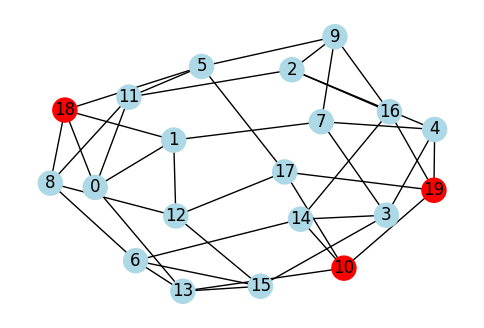

In [57]:
fig,ax = plt.subplots(1,1,figsize=(6,4))
add_graph_plot(G, B, ax)

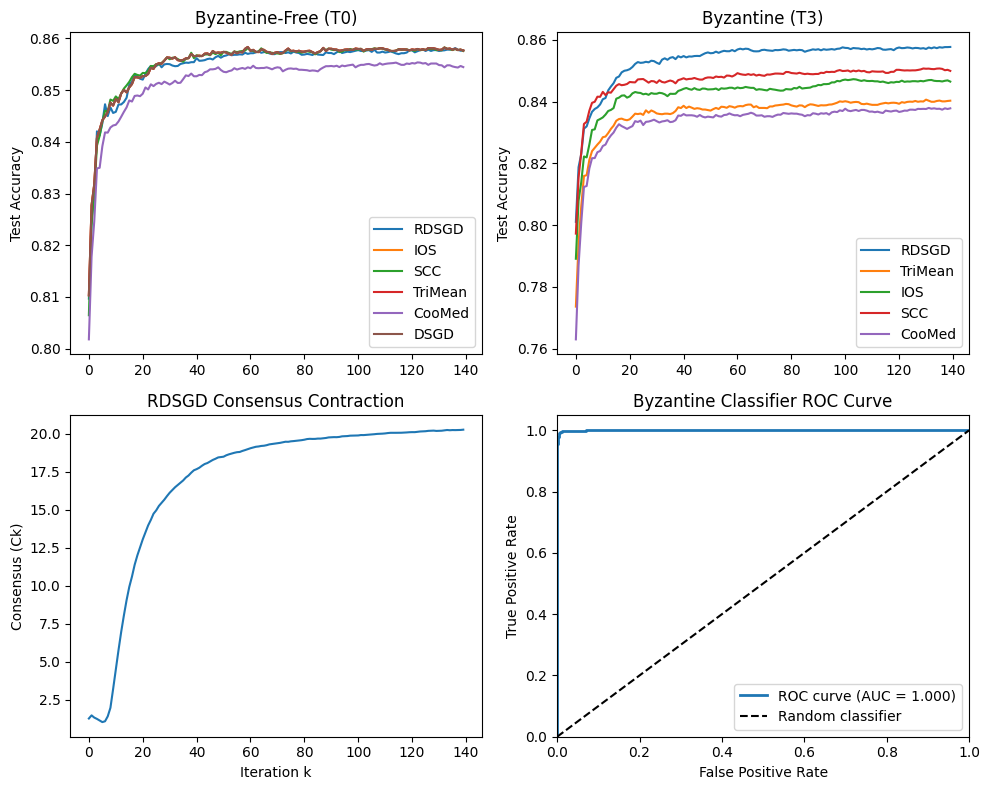

In [58]:
final_ax[0,0].legend()
final_ax[0,1].legend()
final_ax[1,1].legend()
final_fig.tight_layout()
display(final_fig) 

In [59]:
data = config.copy()
rdsgd_consts = calc_rdsgd_constants(W, H, B, models[H], [X_aug[dp[i]] for i in H], C_fpr, C_fnr, run_metrics['proj_const'])
data.update(run_metrics)
data.update(rdsgd_consts)
data_payload = parse(data)
# display(data_payload)

In [60]:
ledger_fname="results.csv"
df_res = pd.DataFrame()
if isLogging:
    final_fig.savefig(f"images/{run_id}.png")
    df_res = pd.read_csv(ledger_fname, index_col='id')
    df_res.loc[run_id] = data_payload
    df_res.to_csv(ledger_fname)